# Analysis of Structural Balance in Signed Financial Networks

This notebook presents a production-grade investigation of structural balance properties and local cohesive structures (fraudster groups) within a signed financial social network. We utilize eigenvalue exponents for global balance quantification ($B_w$), non-binary triangle geometric means, Kolmogorov-Smirnov statistical comparison against weight-shuffled null ensembles, and community detection on suspected actors.

## 1. Setup and Environment Configuration
We load the necessary libraries, auto-reload helpers, and set simulation parameters (e.g. number of randomized null runs).

In [1]:
%load_ext autoreload
%autoreload 2

from auxiliary_functions import *

## 2. Graph Loading and Simplification
We read the raw GEXF network `graph_jupyter.gexf` and simplify it into undirected signed graphs by consolidating parallel links:
- **Continuous Simplified Graph:** Retains the continuous mean weights of parallel edges.
- **Binary Simplified Graph:** Maps consolidated weights to their signs ($-1.0$ or $+1.0$).

In [2]:
std_threshold = 0.5
NumberOfRandoms = 300

# Load raw graph
graph_raw = nx.read_gexf("graph_jupyter.gexf")

# 1. Continuous Graph simplification
graph = simplify_graph(graph_raw, std_threshold, continuous=True)
null_models = [generate_null_model(graph, (214013 * i + 2531011) % (1 << 31)) for i in range(NumberOfRandoms)]

triangles_graph = calculate_triangles_graph(graph)
null_triangles = calculate_triangles_null_graph(null_models)

print(f"Continuous Graph: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges")

Continuous Graph: 5866 nodes, 21219 edges


## 3. Global Exploratory Data Analysis (EDA)
We analyze global edge weights, signs, and triangle configurations.

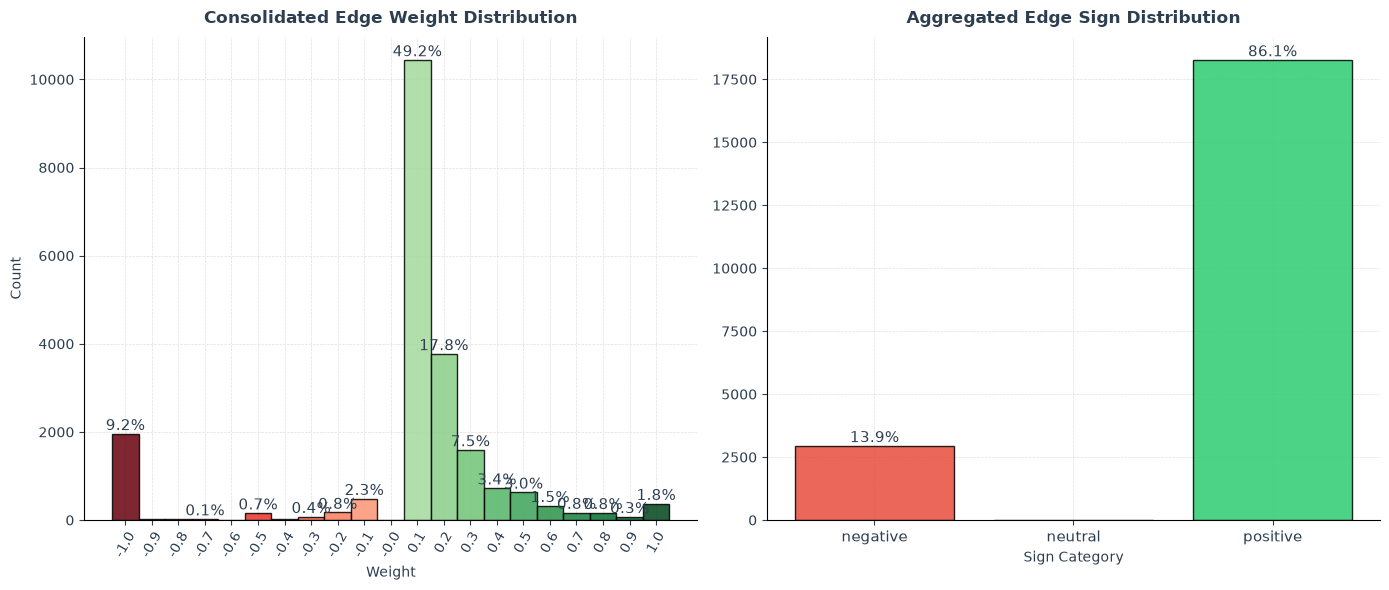

In [3]:
plot_weight_distribution(graph)

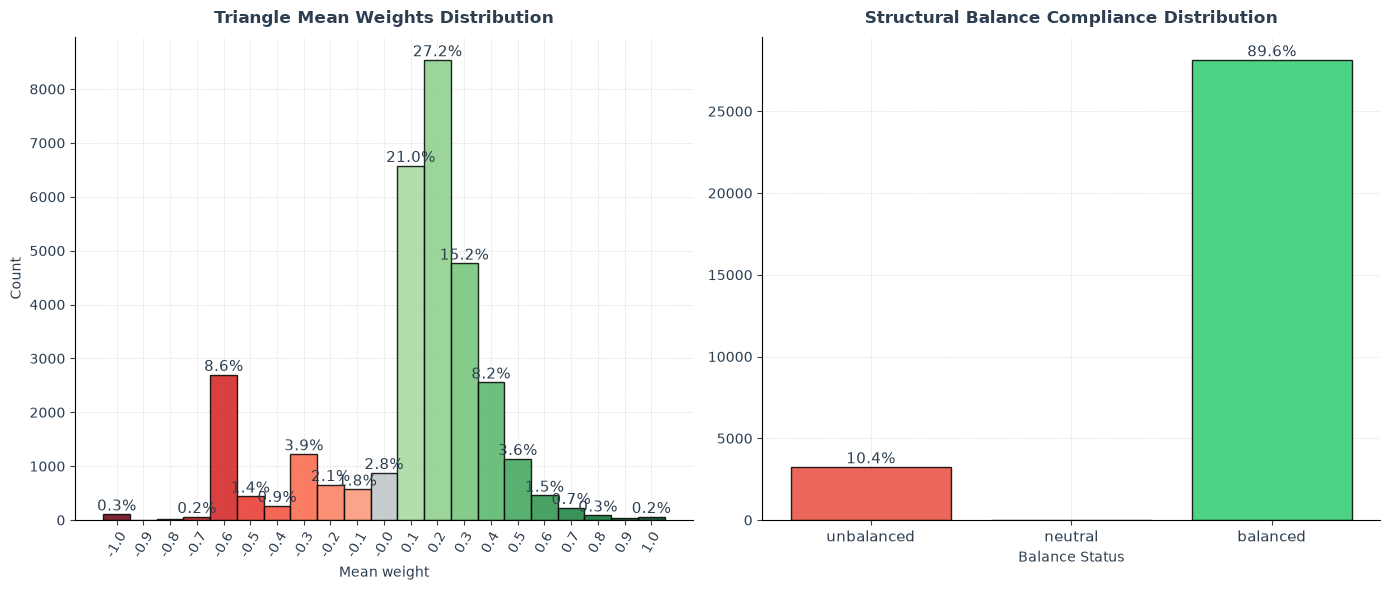

In [4]:
plot_triangle_distribution(triangles_graph)

In [5]:
number_of_triangles_per_type(triangles_graph)

,0 pos edges,1 pos edge,2 pos edges,3 pos edges
0,233,4938,3017,23203


## 4. Ego-Network Analysis of Suspicious Nodes
We extract subgraphs centered on the top-5 nodes with the most negative and $-1.0$ weight incident links to inspect local threat clusters.

In [6]:
negative_graph, negative1_graph = extract_ego_subgraphs(graph, k=5)

Top nodes with most negative links: ['2125', '1810', '2266', '3744', '2067']
Top nodes with most -1.0 links: ['1810', '2125', '3744', '4172', '2067']

Negative Subgraph: 997 nodes, 4571 edges
Negative1 Subgraph: 1076 nodes, 5261 edges


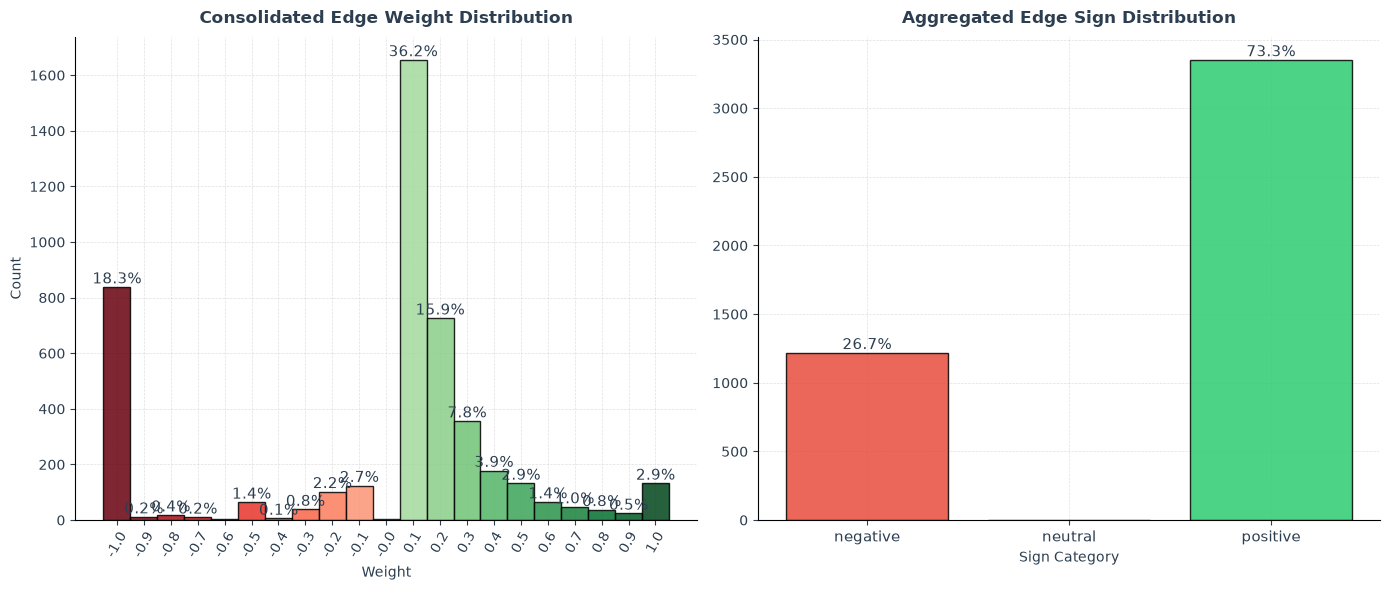

In [7]:
plot_weight_distribution(negative_graph)

In [8]:
# Null models for negative subgraphs
negative_null_models = [generate_null_model(negative_graph, (214013 * i + 2531011) % (1 << 31)) for i in range(NumberOfRandoms)]
negative1_null_models = [generate_null_model(negative1_graph, (214013 * i + 2531011) % (1 << 31)) for i in range(NumberOfRandoms)]

negative_triangles_graph = calculate_triangles_graph(negative_graph)
negative1_triangles_graph = calculate_triangles_graph(negative1_graph)
negative_null_triangles = calculate_triangles_null_graph(negative_null_models)
negative1_null_triangles = calculate_triangles_null_graph(negative1_null_models)

print("Negative Graph Balance Stats:")
print(get_balance_analysis_results(negative_graph, negative_null_models, NumberOfRandoms, recompute=False, cache_path='negative_distribution.json')[0])
print("\nNegative1 Graph Balance Stats:")
print(get_balance_analysis_results(negative1_graph, negative1_null_models, NumberOfRandoms, recompute=False, cache_path='negative1_distribution.json')[0])

Negative Graph Balance Stats:
{'bw': 0.006336628192440883, 'mean': 0.04082722845143287, 'std': 0.0015879780161596685, 'z-score': -21.71982225698773, 'percentile': 0.0}

Negative1 Graph Balance Stats:
{'bw': 0.005954067199464587, 'mean': 0.03565949359718481, 'std': 0.0014218889146452795, 'z-score': -20.89152400849181, 'percentile': 0.0}


Negative Graph Triangle Configurations:
   0 pos edges  1 pos edge  2 pos edges  3 pos edges
0          187        2598         1139         7328

Negative1 Graph Triangle Configurations:
   0 pos edges  1 pos edge  2 pos edges  3 pos edges
0          189        2624         1334         9295


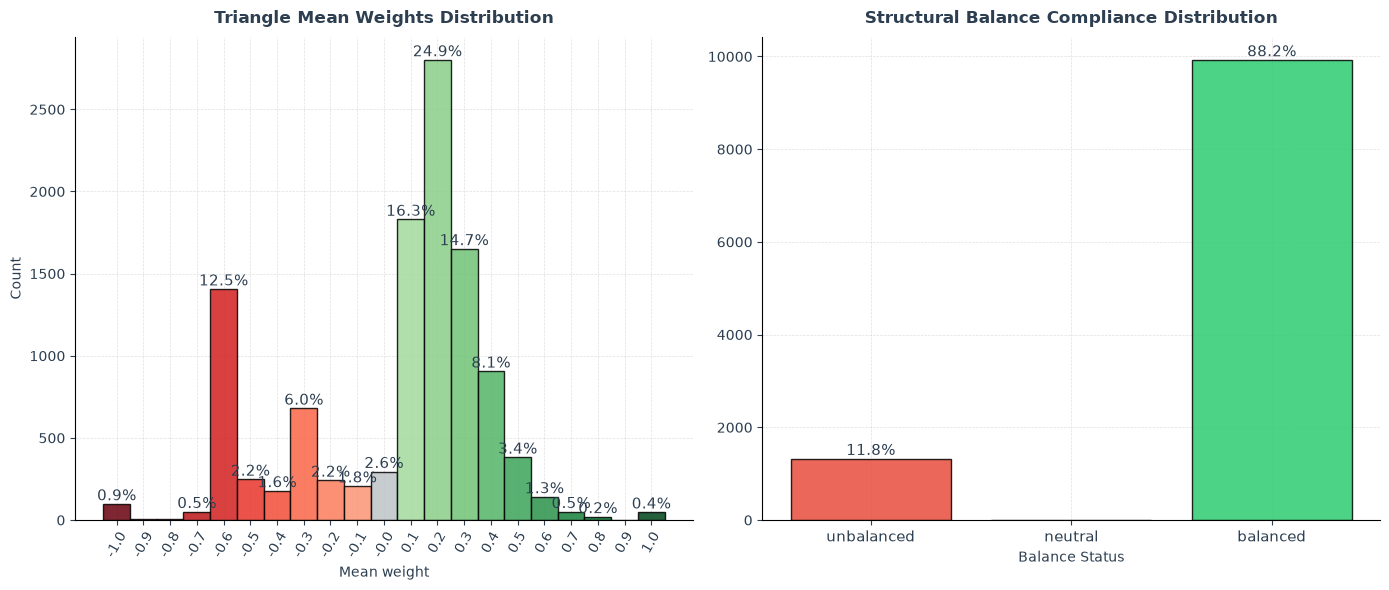

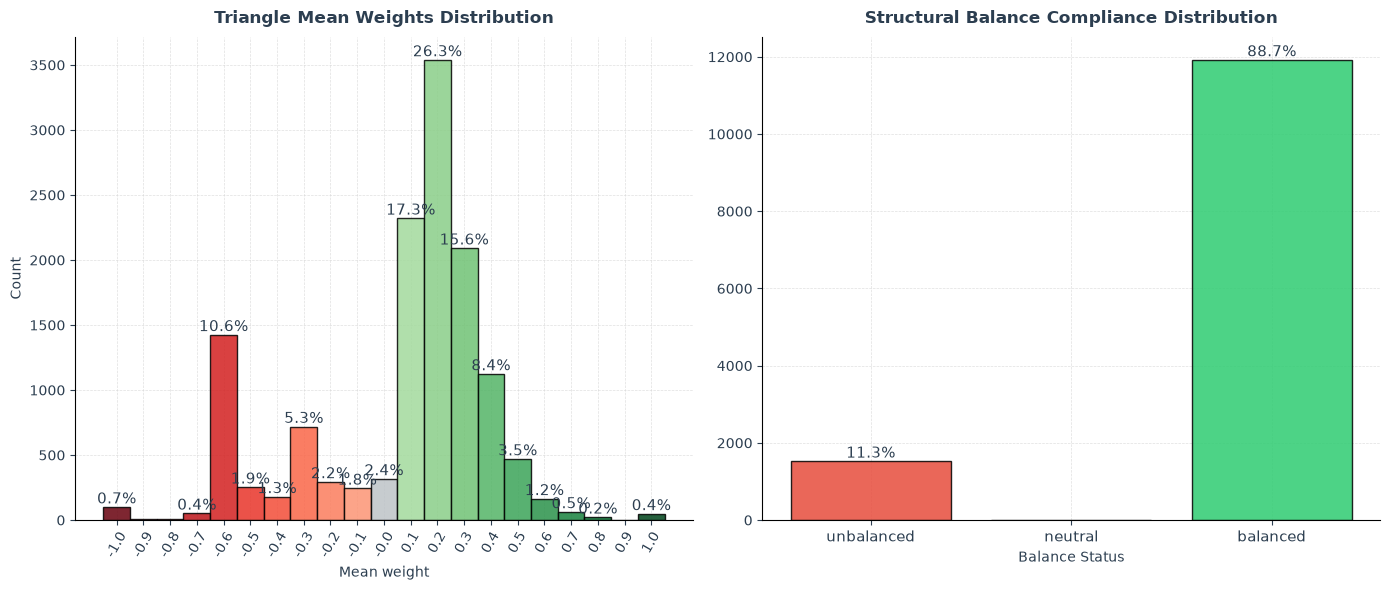

In [9]:
print("Negative Graph Triangle Configurations:")
print(number_of_triangles_per_type(negative_triangles_graph))
print("\nNegative1 Graph Triangle Configurations:")
print(number_of_triangles_per_type(negative1_triangles_graph))

plot_triangle_distribution(negative_triangles_graph)
plot_triangle_distribution(negative1_triangles_graph)

## 5. Continuous Graph Global Balance ($B_w$ Metric)
We analyze global balance using the continuous graph weights. We call `get_balance_analysis_results` with `recompute=False` to load the null distribution from cache (`distribution.json`). Toggle `recompute=True` to run the Monte Carlo simulation from scratch.

In [10]:
results_b, distributions_b = get_balance_analysis_results(
    graph, 
    null_models, 
    NumberOfRandoms, 
    recompute=False, 
    cache_path='distribution.json'
)
results_b

{'bw': 0.006356191342772433,
 'mean': 0.022409856500000002,
 'std': 0.0008559929050341188,
 'z-score': -18.754437172102133,
 'percentile': 0.0}

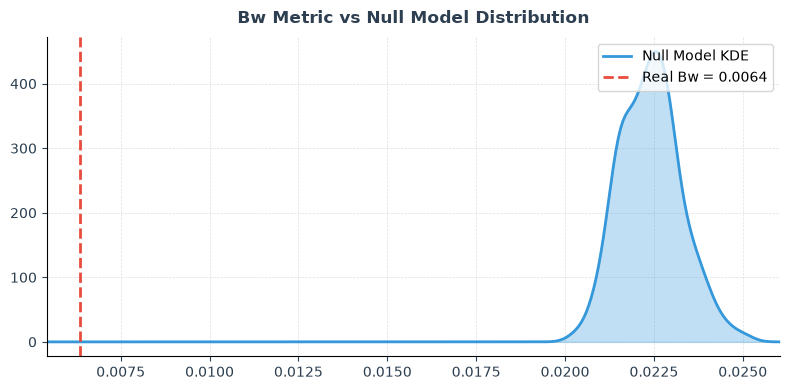

In [11]:
plot_bw_distribution(distributions_b, results_b)

We calculate the Kolmogorov-Smirnov statistics of the continuous graph and plot it.

In [12]:
D_results, D_distribution = calculate_kolmogorov_stats(triangles_graph, null_triangles)
D_results

{'D': 8716.703333333335,
 'mean': 298.63407777777775,
 'std': 118.50121446979425,
 'z-score': 71.03783107388583,
 'percentile': 100.0}

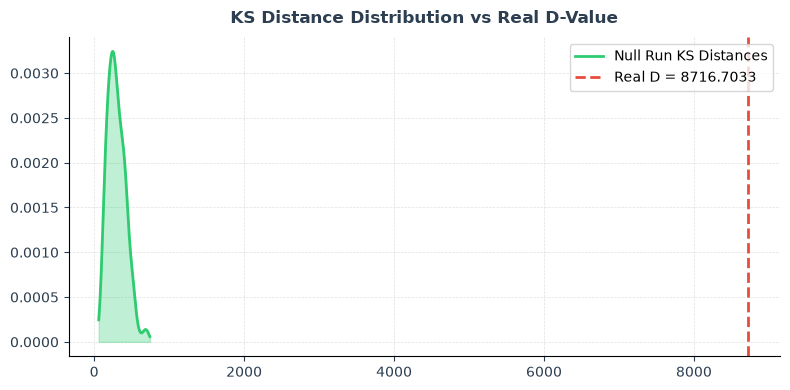

In [13]:
plot_kolmogorov(D_distribution, D_results)

## 6. Binary Graph Global Balance ($B_w$ Metric)
We repeat the global balance analysis for the binary simplified graph, using precomputed cache `BINARYdistributions_b.json` by default.

In [14]:
BINARYgraph = simplify_graph(graph_raw, std_threshold, continuous=False)
BINARYnull_models = [generate_null_model(BINARYgraph, (214013 * i + 2531011) % (1 << 31)) for i in range(NumberOfRandoms)]
BINARYtriangles_graph = calculate_triangles_graph(BINARYgraph)
BINARYnull_triangles = calculate_triangles_null_graph(BINARYnull_models)

print(f"Binary Graph: {BINARYgraph.number_of_nodes()} nodes, {BINARYgraph.number_of_edges()} edges")

Binary Graph: 5866 nodes, 21219 edges


In [15]:
BINARYresults_b, BINARYdistributions_b = get_balance_analysis_results(
    BINARYgraph, 
    BINARYnull_models, 
    NumberOfRandoms, 
    recompute=False, 
    cache_path='BINARYdistributions_b.json'
)
BINARYresults_b

{'bw': 0.0063561913427724395,
 'mean': 0.022248937835484036,
 'std': 0.0007445656242391126,
 'z-score': -21.344990925350242,
 'percentile': 0.0}

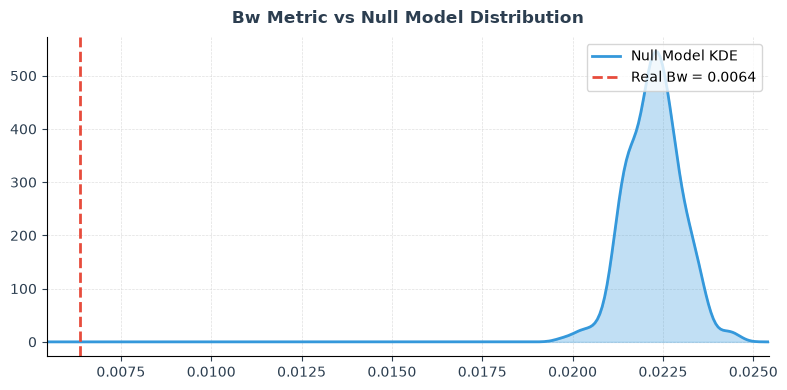

In [16]:
plot_bw_distribution(BINARYdistributions_b, BINARYresults_b)

In [17]:
BINARY_D_results, BINARY_D_distribution = calculate_kolmogorov_stats(BINARYtriangles_graph, BINARYnull_triangles)
BINARY_D_results

{'D': 6524.266666666666,
 'mean': 159.76844444444444,
 'std': 121.1334238846764,
 'z-score': 52.541222877357654,
 'percentile': 100.0}

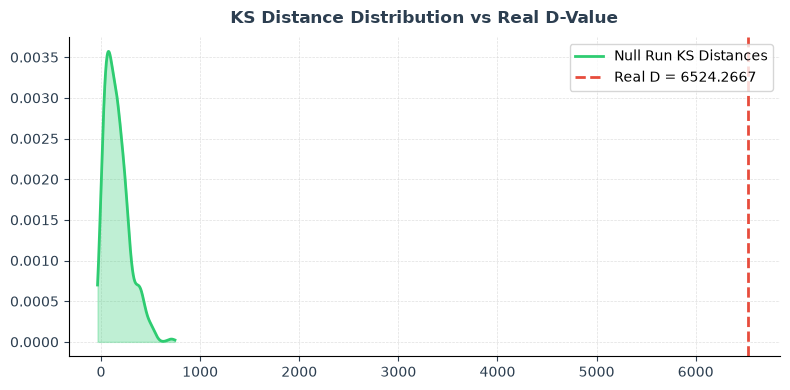

In [18]:
plot_kolmogorov(BINARY_D_distribution, BINARY_D_results)

## 7. Local Node-Level Profiling (Top-5 Degrees)
We analyze the local signed neighborhoods and balance statistics for the top-5 nodes by degree.

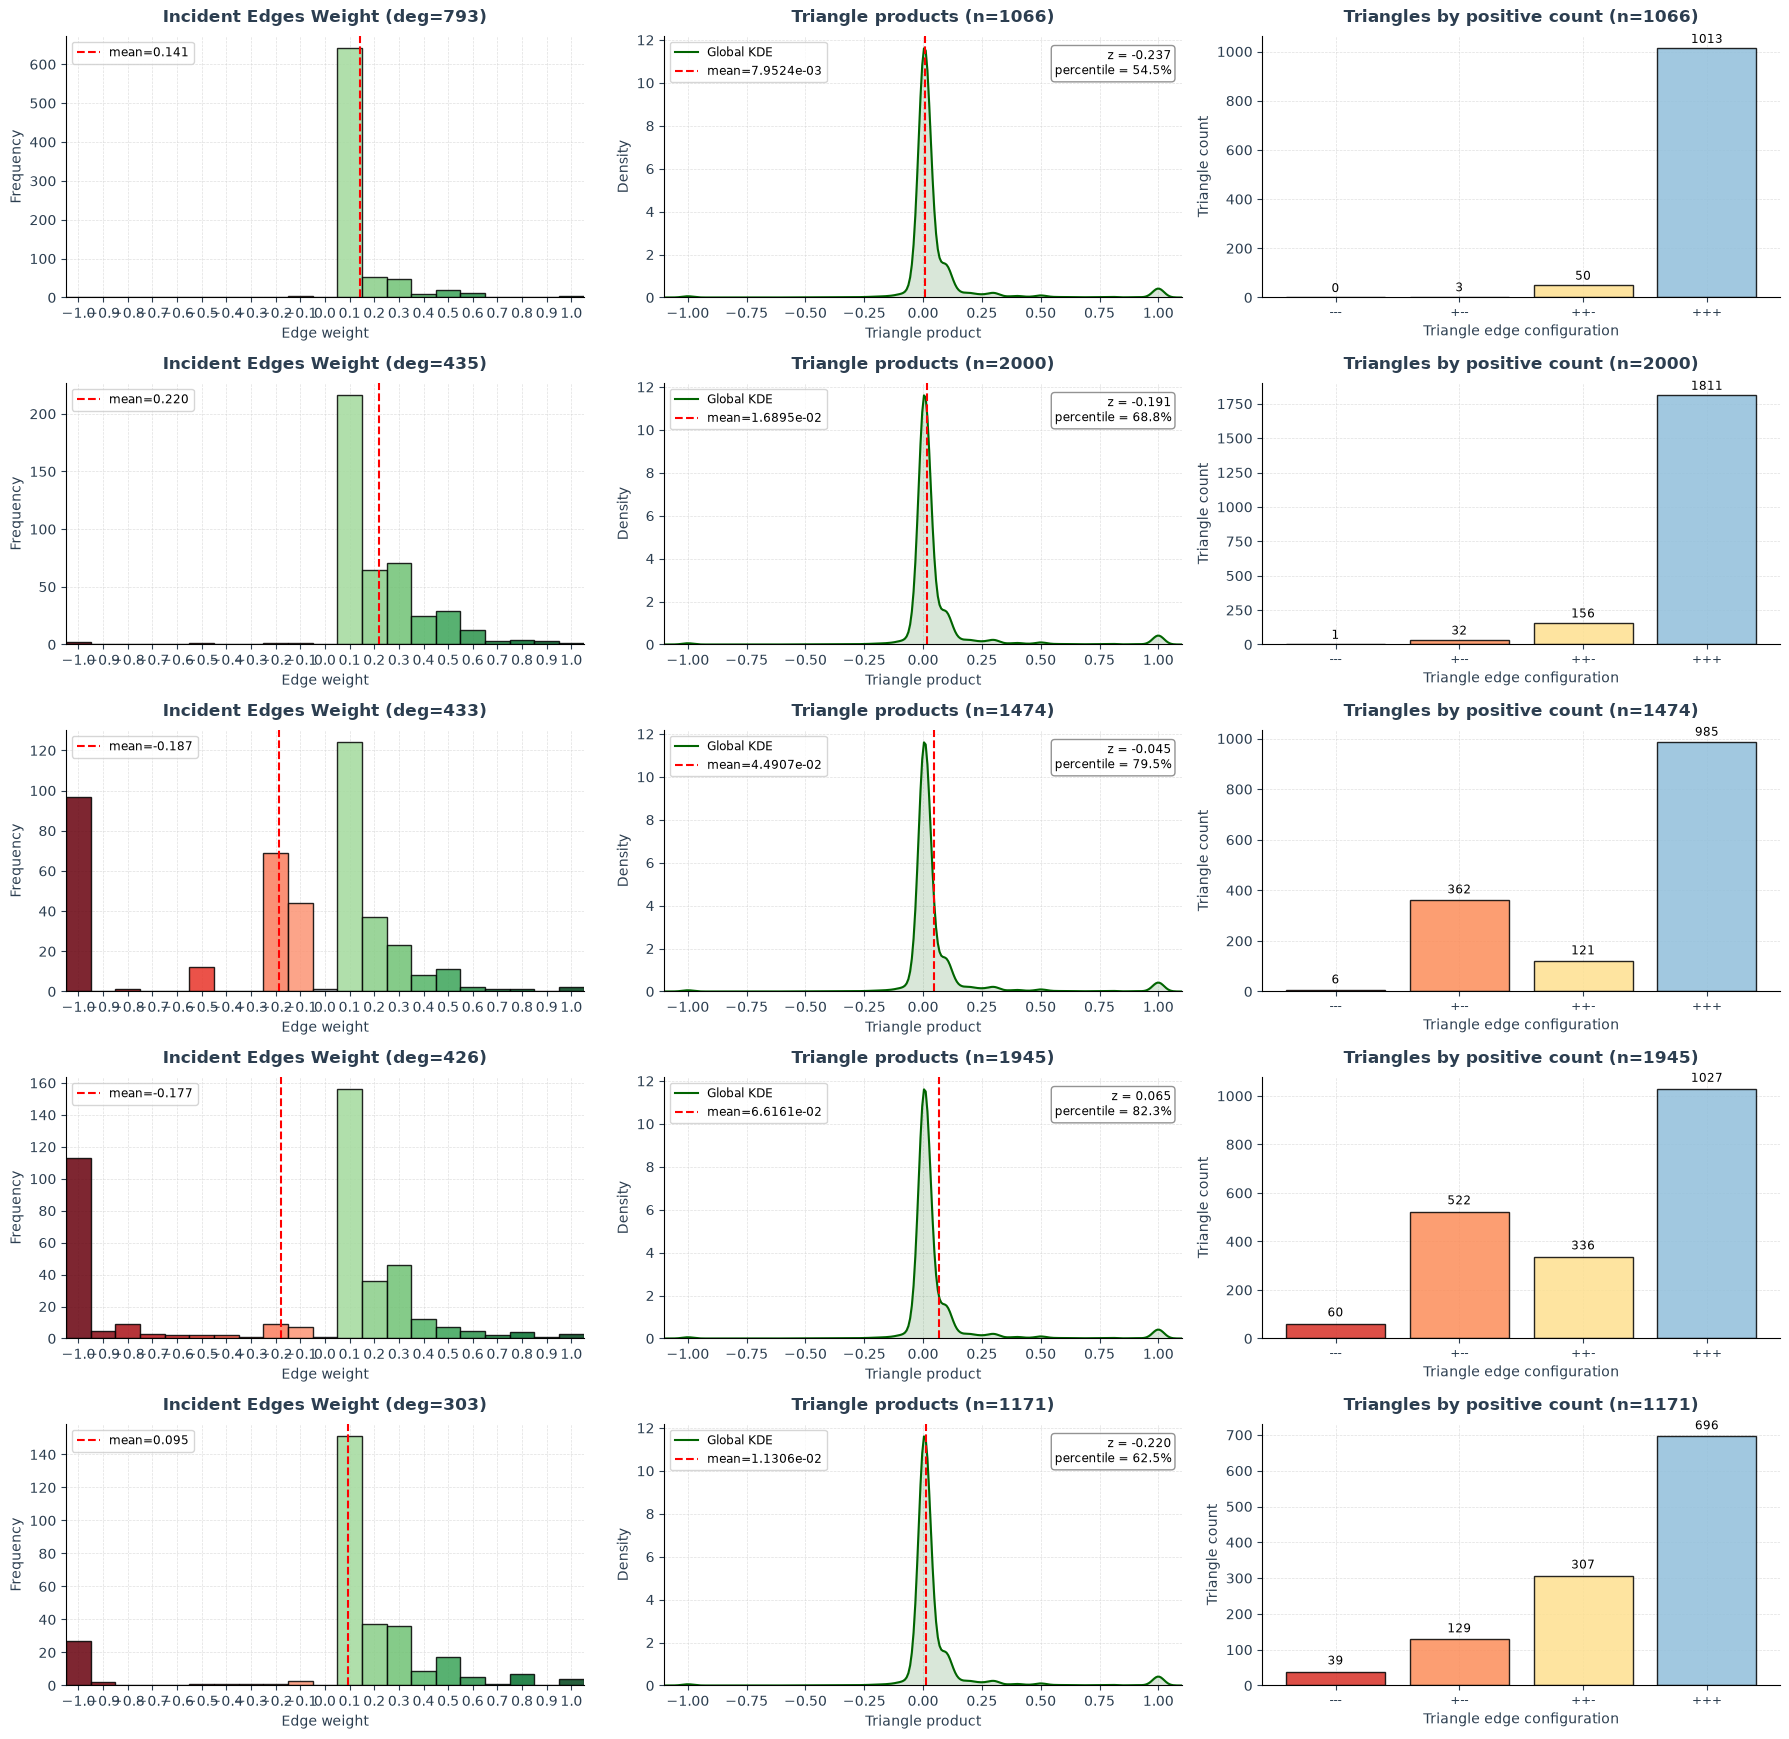

In [19]:
top_nodes_stats(graph, 5)

## 8. Cohesive Fraudster Group Detection
We run our candidate-based community detection algorithm to identify cohesive, suspicious fraud groups across three parameter settings.

Config 1 (Relaxed): Detected 10 fraudster groups.


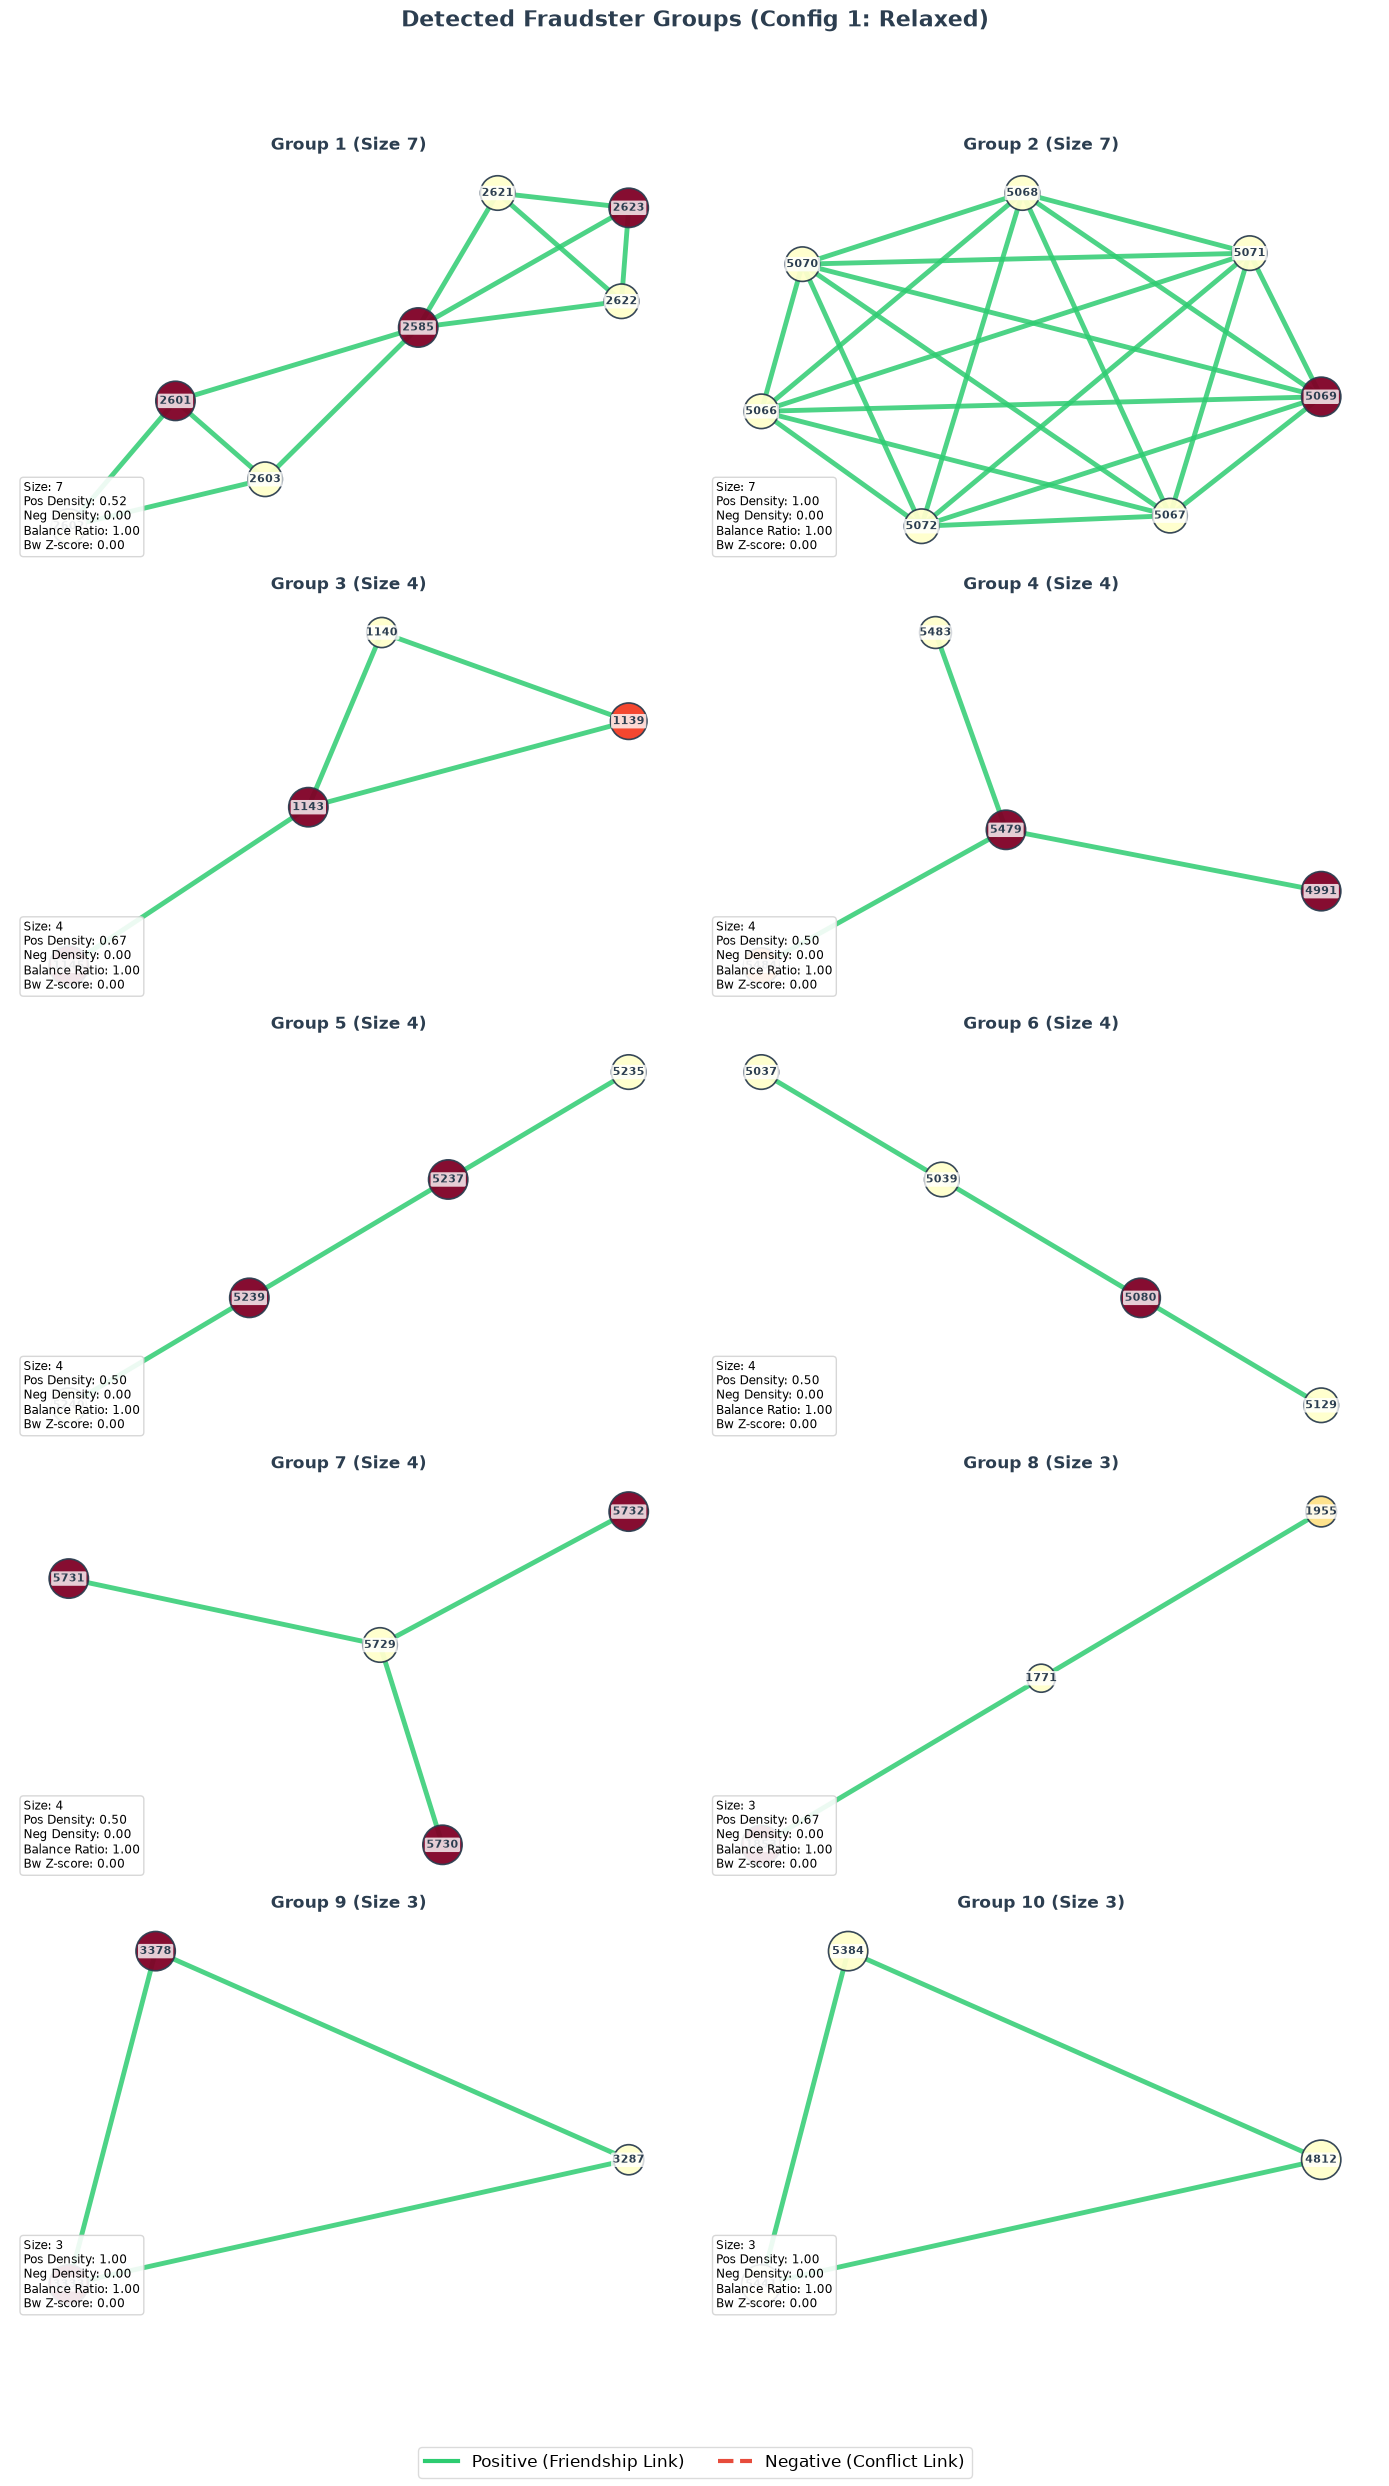

Config 2 (Moderate): Detected 4 fraudster groups.


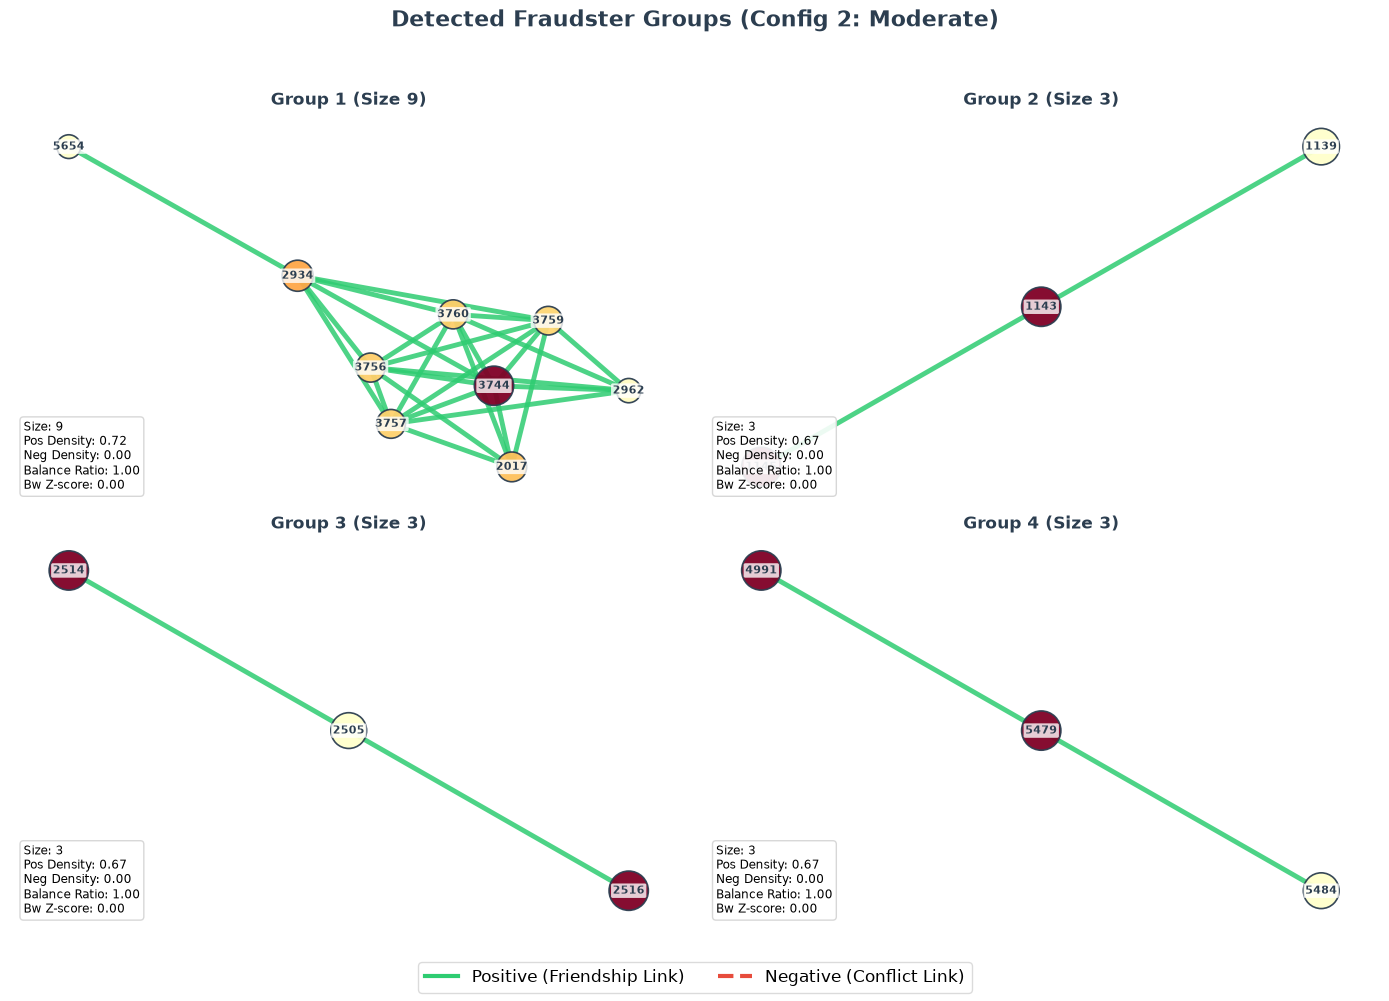

Config 3 (Strict): Detected 2 fraudster groups.


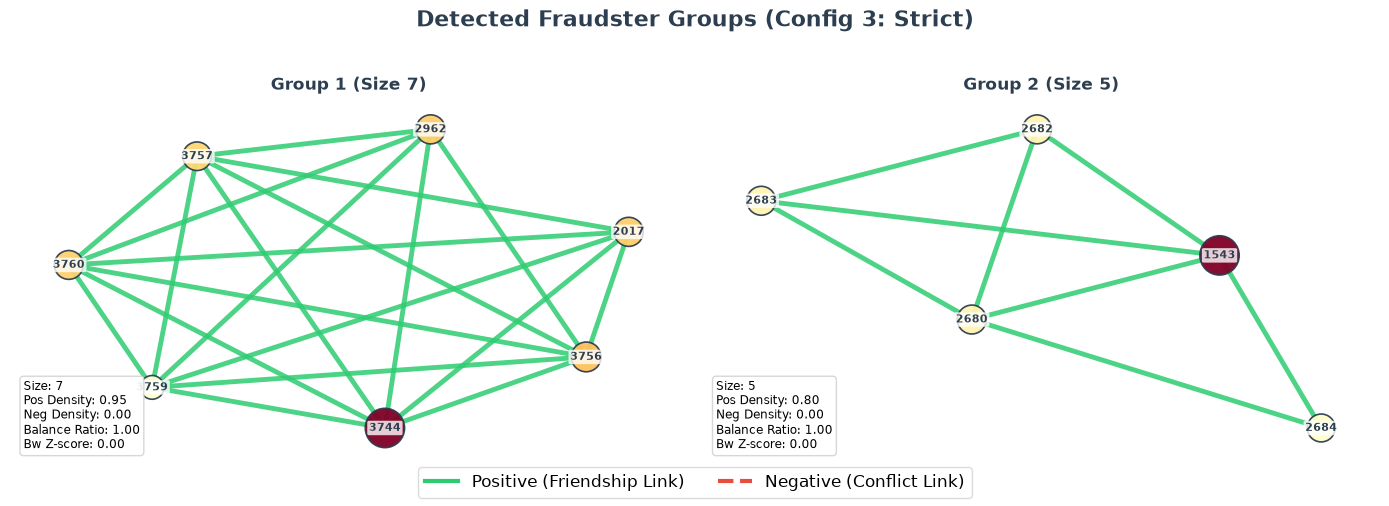

In [27]:
from auxiliary_functions import detect_fraudster_groups, plot_all_fraudster_groups

# Configuration 1: Relaxed Parameters
groups_c1 = detect_fraudster_groups(BINARYgraph, min_neg_degree=2, min_pos_density=0.5, min_balance_ratio=0.8, NumberOfRandoms=NumberOfRandoms)
print(f"Config 1 (Relaxed): Detected {len(groups_c1)} fraudster groups.")
if groups_c1:
    plot_all_fraudster_groups(BINARYgraph, groups_c1, title="Detected Fraudster Groups (Config 1: Relaxed)")

# Configuration 2: Moderate Parameters (Recommended)
groups_c2 = detect_fraudster_groups(BINARYgraph, min_neg_degree=3, min_pos_density=0.6, min_balance_ratio=0.85, NumberOfRandoms=NumberOfRandoms)
print(f"Config 2 (Moderate): Detected {len(groups_c2)} fraudster groups.")
if groups_c2:
    plot_all_fraudster_groups(BINARYgraph, groups_c2, title="Detected Fraudster Groups (Config 2: Moderate)")

# Configuration 3: Strict Parameters
groups_c3 = detect_fraudster_groups(BINARYgraph, min_neg_degree=4, min_pos_density=0.7, min_balance_ratio=0.9, NumberOfRandoms=NumberOfRandoms)
print(f"Config 3 (Strict): Detected {len(groups_c3)} fraudster groups.")
if groups_c3:
    plot_all_fraudster_groups(BINARYgraph, groups_c3, title="Detected Fraudster Groups (Config 3: Strict)")


# 11. Ratio-Based Cohesive Fraudster Detection (Subset $S$)

We filter candidate nodes to form a subset $S$ using a negative degree threshold $X \ge 5$ and a negative ratio threshold $Y \ge 70\%$. This isolates nodes that are heavily specialized in malicious or conflict activity. We extract the induced subgraph on $S$, perform community detection using positive weights, and calculate how much of the global network's threat/conflict is covered by each community.

In [29]:
from auxiliary_functions import detect_fraudster_groups_by_ratio, plot_all_fraudster_groups

# Run the ratio-based community detection on BINARYgraph
groups_ratio = detect_fraudster_groups_by_ratio(
    BINARYgraph, 
    min_neg_degree=5, 
    min_neg_ratio=0.7, 
    min_pos_density=0.5, 
    min_balance_ratio=0.8, 
    NumberOfRandoms=NumberOfRandoms
)

print(f"\nDetected {len(groups_ratio)} ratio-based fraudster groups inside subset S.")
for idx, group in enumerate(groups_ratio, 1):
    print(f"\nGroup {idx}:")
    print(f"  Size: {group['size']}")
    print(f"  Pos Density: {group['pos_density']:.4f}")
    print(f"  Neg Density: {group['neg_density']:.4f}")
    print(f"  Internal Negative Edge Coverage: {group['internal_coverage']:.2f}%")
    print(f"  Incident Negative Edge Coverage: {group['incident_coverage']:.2f}%")
    print(f"  Bw Balance Metric: {group['bw']:.4f} (Z-score: {group['bw_zscore']:.2f})")
    
if groups_ratio:
    plot_all_fraudster_groups(BINARYgraph, groups_ratio, title="Ratio-Based Fraudster Groups (Subset S)")

Subset S filtered: 66 candidate nodes.
Running raw exponential search for subsets of size 3, 4, 5 with Z=50.0%...


KeyboardInterrupt: 